In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from shapely import wkt 
from shapely.geometry import Point
from shapely.geometry import box
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose
# import contextily as ctx
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans

import glob
import os
import csv
import ast
import matplotlib.patheffects as path_effects
from matplotlib.ticker import PercentFormatter

# from libpysal import weights

from matplotlib.colors import (
    ListedColormap,
    BoundaryNorm,
    LinearSegmentedColormap,
    TwoSlopeNorm
)

from pathlib import Path

In [2]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)

### Read in source files 

In [3]:
# study area gdfs 
new_ea = gpd.read_file(DATA_DIR / 'miscellaneous/new_ea.json')
new_data_study_area = gpd.read_file(DATA_DIR / 'miscellaneous/new_data_study_area.json')

# PQR sites 
new_sites = gpd.read_file(DATA_DIR / 'miscellaneous/new_sites.json')

# shapefile (all EAs)
filt_all_eas_dem_df = gpd.read_file(DATA_DIR / 'miscellaneous/filt_all_eas_dem_df.json')

### Mapping of EAs and PQR sites 

In [4]:
ea_copy_pqr = new_ea.copy()
ea_copy_pqr = ea_copy_pqr[['ea_code9ch', 'geometry']]
merged_sites_pqr = gpd.sjoin(new_sites, ea_copy_pqr, how = 'inner', predicate = 'intersects')

merged_sites_pqr = merged_sites_pqr[['space_grouping', 'geometry', 'ea_code9ch']].reset_index(drop=True)

grouped_sites_df = merged_sites_pqr.groupby('ea_code9ch').agg({
    'space_grouping': lambda x: list(set(x)),  
})

grouped_sites_df = grouped_sites_df.rename(columns = {'space_grouping':'site_id'})

### 2021 Census Districts 

In [5]:
# read districts shapefile for plotting 
dist_2021 = gpd.read_file(DATA_DIR / 'miscellaneous/district_2021_census.geojson')

In [6]:
### Filter out Study Area Districts 

dist_2021 = gpd.sjoin(
    dist_2021, merged_sites_pqr.to_crs('EPSG:4326'), 
    how="inner", 
    predicate='contains' 
).reset_index(drop=True).drop(columns=['index_right'])

dist_2021 = dist_2021.drop_duplicates(['Name']).reset_index(drop=True)

# reproject to local CRS 
dist_2021_transformed = dist_2021.to_crs(merged_sites_pqr.crs)

district_gdf = dist_2021_transformed.copy()

### Revised EA shapefile  

In [7]:
filt_all_eas_dem_df_filt = gpd.sjoin(
    filt_all_eas_dem_df, dist_2021_transformed.drop(columns = ['ea_code9ch']), 
    how="inner", 
    predicate='intersects' 
).reset_index(drop=True)

## exclude additional EAs around the edges for basemap plotting 
additional_eas_to_exclude = [31400149, 31400142, 31400139, 31400134, 31400133, 30801173, 30801139, 30801138, 30801136, 30801063, 30801062, 30100656, 30100652, 30200407, 30200368, 30801041, 30801001, 30100689, 30200426]

filt_all_eas_dem_df_filt = filt_all_eas_dem_df_filt[
    ~filt_all_eas_dem_df_filt['ea_code9ch'].isin(additional_eas_to_exclude)
]

### EAs n Sites  (6km) 

In [8]:
merged_eas_sites = pd.read_csv(DATA_DIR / 'miscellaneous/ea_site_list_6km_buffer.csv')
merged_eas_sites = merged_eas_sites[['ea_code9ch', 'Intersecting_Sites']]

# Convert the string representation of lists to actual lists
merged_eas_sites['Intersecting_Sites'] = merged_eas_sites['Intersecting_Sites'].apply(ast.literal_eval)

### Read EAs and CESI level `rev_1`

In [9]:
eas_n_cesi_level = pd.read_csv(DATA_DIR / 'miscellaneous/eas_cesi_level_214_eas_rev1.csv').drop(columns = ['Unnamed: 0'])

### Merged sites & (214 EAs) 

In [10]:
merged_eas_sites = merged_eas_sites.merge(eas_n_cesi_level, on = 'ea_code9ch').reset_index(drop=True)

### Explode the site_ids 

In [55]:
merged_eas_sites_exploded = (
    merged_eas_sites
    .explode('Intersecting_Sites', ignore_index=True)
    .rename(columns={'Intersecting_Sites': 'site_id'})
)

merged_eas_sites_exploded['site_id'] = (merged_eas_sites_exploded['site_id'].astype('Int64'))

# merged_eas_sites_exploded.head()

### filter & get site geometries from main `sample df` 

In [13]:
df = pd.read_csv(DATA_DIR / 'miscellaneous/2022-05-01.csv')

df = df[['time', 'respondent_id', 'site_latitude', 'site_longitude', 'voltage', 'frequency', 'site_id']]

In [14]:
site_coords = (
    df.groupby('site_id')[['site_latitude', 'site_longitude']]
      .first()
      .reset_index()
)

merged_df = merged_eas_sites_exploded.merge(
    site_coords,
    on='site_id',
    how='left'
)

### read in 1- & 3-day overlap summary df 

In [29]:
ea_1_3_day_risk_flags = pd.read_csv(DATA_DIR / 'miscellaneous/ea_1_3_day_risk_flags.csv').drop(columns = ['Unnamed: 0'])

In [30]:
ea_1_3_day_risk_flags.head()

,ea_code9ch,event,one_day_risk,three_day_risk,both
0,30200126,L,0,1,0
1,30200184,L,0,1,0
2,30200198,L,1,0,0
3,30200204,L,0,1,0
4,30200266,L,1,0,0


### Merge with the EA & sites df 

In [31]:
merged_risk_df = (
    merged_df
    .merge(
        ea_1_3_day_risk_flags,
        on='ea_code9ch',
        how='left',
        validate='many_to_many'
    )
)

risk_cols = ['one_day_risk', 'three_day_risk', 'both']

merged_risk_df[risk_cols] = (
    merged_risk_df[risk_cols]
    .fillna(0)
    .astype(int)
)

In [32]:
merged_risk_df

,ea_code9ch,site_id,cesi_level,site_latitude,site_longitude,event,one_day_risk,three_day_risk,both
0,30200002,456,Low,5.633024,-0.300601,NaN,0,0,0
1,30200012,430,Low,5.638675,-0.300250,NaN,0,0,0
2,30200013,363,Low,5.640099,-0.291457,NaN,0,0,0
3,30200014,301,Low,5.636135,-0.286370,P,0,1,0
4,30200015,104,Low,5.644859,-0.290894,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...
251,31300310,117,Low,5.689682,-0.186315,W,1,0,0
252,31300328,296,Low,5.711324,-0.185577,NaN,0,0,0
253,31300407,445,Low,5.711772,-0.188362,NaN,0,0,0
254,31300449,228,Low,5.659560,-0.167445,NaN,0,0,0


In [33]:
merged_risk_df = merged_risk_df[['ea_code9ch', 'cesi_level', 'event', 'one_day_risk', 'three_day_risk', 'both']].reset_index(
                                                                                                drop=True)

merged_risk_df_w_geoms = merged_risk_df.merge(filt_all_eas_dem_df_filt[['ea_code9ch', 'geometry']], on = 'ea_code9ch', how = 'left').drop_duplicates(subset=['ea_code9ch', 'event'])
merged_risk_df_w_geoms = merged_risk_df_w_geoms.reset_index(drop=True)

merged_risk_gdf = gpd.GeoDataFrame(
    merged_risk_df_w_geoms.copy(),
    geometry="geometry",
    crs="EPSG:32630"
)

In [34]:
merged_risk_gdf

,ea_code9ch,cesi_level,event,one_day_risk,three_day_risk,both,geometry
0,30200002,Low,NaN,0,0,0,"POLYGON ((799017.814 623458.371, 799051.565 62..."
1,30200012,Low,NaN,0,0,0,"POLYGON ((799328.799 623914.862, 799292 623916..."
2,30200013,Low,NaN,0,0,0,"POLYGON ((799909.133 624452.948, 799919.44 624..."
3,30200014,Low,P,0,1,0,"POLYGON ((800503.736 624455.809, 800569.516 62..."
4,30200015,Low,NaN,0,0,0,"POLYGON ((799640.296 624891.197, 799654.316 62..."
...,...,...,...,...,...,...,...
224,31300291,High,NaN,0,0,0,"POLYGON ((813765.805 629305.242, 813853.337 62..."
225,31300310,Low,W,1,0,0,"POLYGON ((811832.487 629333.217, 811643.775 62..."
226,31300328,Low,NaN,0,0,0,"POLYGON ((813036.279 631092.941, 813016.813 63..."
227,31300407,Low,NaN,0,0,0,"POLYGON ((811220.071 632428, 811219.23 632385...."


## Visualize 

### Define x&y offsets, figsize, and x&y axis limits - so the spatial figures are more centered

In [35]:
common_x_ref_offset = 4     # km east if use_km=True
common_y_ref_offset = -1 

fig_size=(10, 8)

common_xlim = (-18, 18)
common_ylim = (-12, 22)

In [57]:
def plot_ea_risk_distances(
    gdf,
    base_gdf=None,

    # Column names
    ea_col="ea_code9ch",
    event_col="event",

    # Event selection
    event_filter=None,
    show_cross_event=False,

    # Reference point
    use_union_centroid=True,
    ref_easting=None,
    ref_northing=None,
    x_ref_offset=0,
    y_ref_offset=0,
    use_km=True,

    # Basemap
    show_basemap=False,
    basemap_facecolor="none",
    basemap_edgecolor="lightgrey",
    basemap_linewidth=0.4,
    basemap_alpha=1.0,

    # Figure
    figsize=(10, 8),

    # Point styling
    point_size=75,
    point_alpha=0.9,
    point_edgecolor="white",
    point_linewidth=0.7,

    # Risk colors
    one_day_color="#2878A5",
    three_day_color="#E68613",
    both_color="#7B2CBF",
    cross_event_color="#7F7F7F",

    # Legend labels
    one_day_label="Same-day",
    three_day_label="3-day window",
    both_label="Both",
    cross_event_label=(
        "Same- and 3-day risk, different events"
    ),

    # Reference lines
    show_reference_lines=True,
    reference_linecolor="black",
    reference_linestyle="--",
    reference_linewidth=1,
    reference_alpha=0.5,

    # Reference point marker
    show_reference_point=False,
    reference_point_size=80,
    reference_point_marker="X",
    reference_point_color="black",

    # Axes
    xlim=None,
    ylim=None,
    show_yaxis=False,
    equal_aspect=True,

    # Axis labels
    x_label=None,
    y_label=None,
    axis_label_fontsize=15,
    axis_label_fontweight="bold",
    axis_labelpad=12,

    # Tick labels
    x_tick_fontsize=12,
    y_tick_fontsize=12,
    x_rotation=0,

    # Annotation
    annotate=False,
    annotation_fontsize=8,

    # Panel label
    panel_label=None,
    panel_label_x=0.02,
    panel_label_y=0.98,
    panel_label_fontsize=16,
    panel_label_fontweight="bold",
    panel_label_ha="left",
    panel_label_va="top",

    # Title
    title=None,
    title_fontsize=15,
    title_fontweight="bold",
    title_pad=12,

    # Legend
    show_legend=True,
    legend_title=None,
    legend_loc="upper left",
    legend_bbox=None,
    legend_fontsize=12,
    legend_title_fontsize=12,
    legend_marker_size=10,
    legend_frame=True,
    legend_facecolor="white",
    legend_edgecolor="grey",
    legend_framealpha=0.9,

    # Diagnostics
    diagnostics=False,

    # Saving
    save_path=None,
    dpi=300
):
    """
    Plot EA centroids according to same-day and 3-day increased-risk
    categories.

    Parameters
    ----------
    gdf : GeoDataFrame
        Risk GeoDataFrame containing EA polygons and the columns:
        event, one_day_risk, three_day_risk, and both.

    base_gdf : GeoDataFrame or None
        Optional separate EA GeoDataFrame used as the basemap and
        for calculating the union-centroid reference point.

        If None, the EA polygons in `gdf` are used.

    event_filter : None, str, or list-like
        None:
            Combine all available events.

        str:
            Select one event, such as "T".

        list-like:
            Combine selected events, such as ["T", "P"].

    show_cross_event : bool
        If True, distinguish EAs where the same-day and 3-day risks
        occurred for different events.

        If False, all EAs having both risk durations are shown using
        the general "both" category.
    """

    import numpy as np
    import geopandas as gpd
    import matplotlib.pyplot as plt

    from matplotlib.lines import Line2D
    from shapely import affinity

    # =================================================
    # Helper: clean and dissolve an EA GeoDataFrame
    # =================================================
    def prepare_ea_polygons(input_gdf, name):
        prepared = gpd.GeoDataFrame(
            input_gdf.copy(),
            geometry="geometry",
            crs=getattr(input_gdf, "crs", None)
        )

        if prepared.crs is None:
            raise ValueError(
                f"{name} must have a defined CRS."
            )

        if prepared.crs.is_geographic:
            raise ValueError(
                f"{name} must use a projected CRS. "
                "For Greater Accra, use EPSG:32630."
            )

        required = {ea_col, "geometry"}
        missing = required - set(prepared.columns)

        if missing:
            raise ValueError(
                f"{name} is missing columns: "
                f"{sorted(missing)}"
            )

        prepared = prepared.dropna(
            subset=[ea_col, "geometry"]
        ).copy()

        prepared = prepared[
            ~prepared.geometry.is_empty
        ].copy()

        prepared[ea_col] = (
            prepared[ea_col]
            .astype(str)
            .str.strip()
        )

        invalid_mask = ~prepared.geometry.is_valid

        if invalid_mask.any():
            prepared.loc[
                invalid_mask,
                "geometry"
            ] = (
                prepared.loc[
                    invalid_mask,
                    "geometry"
                ]
                .buffer(0)
            )

        prepared = (
            prepared[[ea_col, "geometry"]]
            .dissolve(
                by=ea_col,
                as_index=False
            )
        )

        return gpd.GeoDataFrame(
            prepared,
            geometry="geometry",
            crs=input_gdf.crs
        )

    # =================================================
    # Prepare risk GeoDataFrame
    # =================================================
    risk_gdf = gpd.GeoDataFrame(
        gdf.copy(),
        geometry="geometry",
        crs=getattr(gdf, "crs", None)
    )

    required_risk_cols = {
        ea_col,
        event_col,
        "one_day_risk",
        "three_day_risk",
        "both",
        "geometry"
    }

    missing_risk_cols = (
        required_risk_cols - set(risk_gdf.columns)
    )

    if missing_risk_cols:
        raise ValueError(
            "gdf is missing required columns: "
            f"{sorted(missing_risk_cols)}"
        )

    if risk_gdf.crs is None:
        raise ValueError(
            "gdf must have a defined CRS."
        )

    if risk_gdf.crs.is_geographic:
        raise ValueError(
            "gdf must use a projected CRS. "
            "For Greater Accra, use EPSG:32630."
        )

    risk_gdf = risk_gdf.dropna(
        subset=[ea_col, "geometry"]
    ).copy()

    risk_gdf = risk_gdf[
        ~risk_gdf.geometry.is_empty
    ].copy()

    risk_gdf[ea_col] = (
        risk_gdf[ea_col]
        .astype(str)
        .str.strip()
    )

    risk_gdf[event_col] = (
        risk_gdf[event_col]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    risk_cols = [
        "one_day_risk",
        "three_day_risk",
        "both"
    ]

    risk_gdf[risk_cols] = (
        risk_gdf[risk_cols]
        .fillna(0)
        .astype(int)
    )

    invalid_mask = ~risk_gdf.geometry.is_valid

    if invalid_mask.any():
        risk_gdf.loc[
            invalid_mask,
            "geometry"
        ] = (
            risk_gdf.loc[
                invalid_mask,
                "geometry"
            ]
            .buffer(0)
        )

    # One risk polygon per EA
    risk_polygons = prepare_ea_polygons(
        risk_gdf,
        name="gdf"
    )

    # =================================================
    # Prepare separate basemap, if supplied
    # =================================================
    if base_gdf is not None:
        basemap_polygons = prepare_ea_polygons(
            base_gdf,
            name="base_gdf"
        )

        # Match risk-data CRS
        if basemap_polygons.crs != risk_gdf.crs:
            basemap_polygons = (
                basemap_polygons.to_crs(
                    risk_gdf.crs
                )
            )

    else:
        basemap_polygons = risk_polygons.copy()

    # =================================================
    # Select events
    # =================================================
    available_events = sorted(
        risk_gdf[event_col]
        .dropna()
        .unique()
        .tolist()
    )

    if event_filter is None:
        selected_events = available_events

    elif isinstance(event_filter, str):
        selected_events = [
            event_filter.strip().upper()
        ]

    else:
        selected_events = [
            str(event).strip().upper()
            for event in event_filter
        ]

    missing_events = [
        event
        for event in selected_events
        if event not in available_events
    ]

    if missing_events:
        raise ValueError(
            f"Events not found: {missing_events}. "
            f"Available events are: {available_events}"
        )

    if not selected_events:
        raise ValueError(
            "No valid events are available for plotting."
        )

    selected = risk_gdf[
        risk_gdf[event_col].isin(
            selected_events
        )
    ].copy()

    # Retain only increased-risk rows
    selected = selected[
        selected[risk_cols].max(axis=1).eq(1)
    ].copy()

    if selected.empty:
        raise ValueError(
            "No increased-risk EAs were found for "
            "the selected event or events."
        )

    # =================================================
    # Collapse selected event rows to one row per EA
    # =================================================
    ea_risk = (
        selected
        .groupby(ea_col, as_index=False)
        .agg(
            one_day_risk=(
                "one_day_risk",
                "max"
            ),
            three_day_risk=(
                "three_day_risk",
                "max"
            ),
            both=(
                "both",
                "max"
            ),
            selected_event_count=(
                event_col,
                "nunique"
            )
        )
    )

    # Mutually exclusive risk categories
    conditions = [
        # Both risks within at least one identical event
        ea_risk["both"].eq(1),

        # Same-day only
        (
            ea_risk["one_day_risk"].eq(1)
            & ea_risk["three_day_risk"].eq(0)
        ),

        # 3-day only
        (
            ea_risk["one_day_risk"].eq(0)
            & ea_risk["three_day_risk"].eq(1)
        ),

        # Both durations, but across different events
        (
            ea_risk["one_day_risk"].eq(1)
            & ea_risk["three_day_risk"].eq(1)
            & ea_risk["both"].eq(0)
        )
    ]

    choices = [
        "both_same_event",
        "one_day_only",
        "three_day_only",
        "both_different_events"
    ]

    ea_risk["risk_category"] = np.select(
        conditions,
        choices,
        default="no_risk"
    )

    # Combine both categories unless requested separately
    if not show_cross_event:
        ea_risk.loc[
            ea_risk["risk_category"].eq(
                "both_different_events"
            ),
            "risk_category"
        ] = "both_same_event"

    # =================================================
    # Join risk results to EA polygons
    # =================================================
    ea_plot = risk_polygons.merge(
        ea_risk,
        on=ea_col,
        how="inner",
        validate="one_to_one"
    )

    ea_plot = gpd.GeoDataFrame(
        ea_plot,
        geometry="geometry",
        crs=risk_polygons.crs
    )

    if ea_plot.empty:
        raise ValueError(
            "No EA polygons matched the selected "
            "risk results."
        )

    # =================================================
    # Calculate EA centroids
    # =================================================
    ea_centroids = ea_plot.copy()

    ea_centroids["geometry"] = (
        ea_plot.geometry.centroid
    )

    ea_centroids["easting"] = (
        ea_centroids.geometry.x
    )

    ea_centroids["northing"] = (
        ea_centroids.geometry.y
    )

    # =================================================
    # Define reference point
    # =================================================
    if use_union_centroid:
        try:
            base_union = (
                basemap_polygons.geometry.union_all()
            )
        except Exception:
            base_union = (
                basemap_polygons.geometry.unary_union
            )

        reference_point = base_union.centroid

        ref_easting = reference_point.x
        ref_northing = reference_point.y

    else:
        if (
            ref_easting is None
            or ref_northing is None
        ):
            raise ValueError(
                "Provide both ref_easting and "
                "ref_northing when "
                "use_union_centroid=False."
            )

    # =================================================
    # Apply offsets and choose units
    # =================================================
    if use_km:
        ref_easting += x_ref_offset * 1000
        ref_northing += y_ref_offset * 1000

        conversion_factor = 1000
        unit_label = "km"

    else:
        ref_easting += x_ref_offset
        ref_northing += y_ref_offset

        conversion_factor = 1
        unit_label = "m"

    # Coordinates relative to reference point
    ea_centroids["x_distance"] = (
        ea_centroids["easting"]
        - ref_easting
    ) / conversion_factor

    ea_centroids["y_distance"] = (
        ea_centroids["northing"]
        - ref_northing
    ) / conversion_factor

    # =================================================
    # Plotting configuration
    # =================================================
    category_styles = {
        "one_day_only": {
            "color": one_day_color,
            "label": one_day_label,
            "zorder": 3
        },
        "three_day_only": {
            "color": three_day_color,
            "label": three_day_label,
            "zorder": 3
        },
        "both_same_event": {
            "color": both_color,
            "label": both_label,
            "zorder": 5
        },
        "both_different_events": {
            "color": cross_event_color,
            "label": cross_event_label,
            "zorder": 4
        }
    }

    category_order = [
        "one_day_only",
        "three_day_only",
        "both_same_event"
    ]

    if show_cross_event:
        category_order.append(
            "both_different_events"
        )

    # =================================================
    # Create figure
    # =================================================
    fig, ax = plt.subplots(
        figsize=figsize
    )

    # =================================================
    # Plot optional basemap
    # =================================================
    if show_basemap:
        relative_base = basemap_polygons.copy()

        relative_base["geometry"] = (
            relative_base.geometry.apply(
                lambda geom: affinity.scale(
                    affinity.translate(
                        geom,
                        xoff=-ref_easting,
                        yoff=-ref_northing
                    ),
                    xfact=1 / conversion_factor,
                    yfact=1 / conversion_factor,
                    origin=(0, 0)
                )
            )
        )

        relative_base.plot(
            ax=ax,
            facecolor=basemap_facecolor,
            edgecolor=basemap_edgecolor,
            linewidth=basemap_linewidth,
            alpha=basemap_alpha,
            zorder=1
        )

    # =================================================
    # Plot EA centroids
    # =================================================
    observed_categories = []

    for category in category_order:
        category_data = ea_centroids[
            ea_centroids["risk_category"].eq(
                category
            )
        ]

        if category_data.empty:
            continue

        observed_categories.append(category)

        style = category_styles[category]

        ax.scatter(
            category_data["x_distance"],
            category_data["y_distance"],
            s=point_size,
            color=style["color"],
            edgecolors=point_edgecolor,
            linewidths=point_linewidth,
            alpha=point_alpha,
            zorder=style["zorder"]
        )

    # =================================================
    # Reference lines
    # =================================================
    if show_reference_lines:
        ax.axhline(
            0,
            color=reference_linecolor,
            linestyle=reference_linestyle,
            linewidth=reference_linewidth,
            alpha=reference_alpha,
            zorder=2
        )

        ax.axvline(
            0,
            color=reference_linecolor,
            linestyle=reference_linestyle,
            linewidth=reference_linewidth,
            alpha=reference_alpha,
            zorder=2
        )

    if show_reference_point:
        ax.scatter(
            0,
            0,
            s=reference_point_size,
            color=reference_point_color,
            marker=reference_point_marker,
            zorder=6
        )

    # =================================================
    # Optional EA annotations
    # =================================================
    if annotate:
        for _, row in ea_centroids.iterrows():
            ax.annotate(
                str(row[ea_col]),
                (
                    row["x_distance"],
                    row["y_distance"]
                ),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=annotation_fontsize
            )

    # =================================================
    # Axis labels
    # =================================================
    if x_label is None:
        x_label = (
            f"East–west distance from reference "
            f"({unit_label})"
        )

    if y_label is None:
        y_label = (
            f"North–south distance from reference "
            f"({unit_label})"
        )

    ax.set_xlabel(
        x_label,
        fontsize=axis_label_fontsize,
        fontweight=axis_label_fontweight,
        labelpad=axis_labelpad
    )

    if show_yaxis:
        ax.set_ylabel(
            y_label,
            fontsize=axis_label_fontsize,
            fontweight=axis_label_fontweight,
            labelpad=axis_labelpad
        )
    else:
        ax.yaxis.set_visible(False)
        ax.spines["left"].set_visible(False)

    ax.tick_params(
        axis="x",
        labelsize=x_tick_fontsize,
        labelrotation=x_rotation
    )

    ax.tick_params(
        axis="y",
        labelsize=y_tick_fontsize
    )

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    if equal_aspect:
        ax.set_aspect(
            "equal",
            adjustable="box"
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # =================================================
    # Panel label
    # =================================================
    if panel_label is not None:
        ax.text(
            panel_label_x,
            panel_label_y,
            str(panel_label),
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            ha=panel_label_ha,
            va=panel_label_va,
            clip_on=False,
            zorder=10
        )

    # =================================================
    # Title
    # =================================================
    if title is not None:
        ax.set_title(
            title,
            fontsize=title_fontsize,
            fontweight=title_fontweight,
            pad=title_pad
        )

    # =================================================
    # Legend
    # =================================================
    if show_legend and observed_categories:
        legend_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor=(
                    category_styles[category]["color"]
                ),
                markeredgecolor=point_edgecolor,
                markeredgewidth=point_linewidth,
                markersize=legend_marker_size,
                label=(
                    category_styles[category]["label"]
                )
            )
            for category in observed_categories
        ]

        ax.legend(
            handles=legend_handles,
            title=legend_title,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox,
            fontsize=legend_fontsize,
            title_fontsize=legend_title_fontsize,
            frameon=legend_frame,
            facecolor=legend_facecolor,
            edgecolor=legend_edgecolor,
            framealpha=legend_framealpha
        )

    # =================================================
    # Diagnostics
    # =================================================
    if diagnostics:
        event_text = (
            "all events"
            if event_filter is None
            else ", ".join(selected_events)
        )

        basemap_source = (
            "base_gdf"
            if base_gdf is not None
            else "gdf"
        )

        print(f"Events selected: {event_text}")

        print(
            f"Basemap source: {basemap_source}"
        )

        print(
            f"Basemap EAs: "
            f"{basemap_polygons[ea_col].nunique()}"
        )

        print(
            f"Risk EAs plotted: "
            f"{ea_centroids[ea_col].nunique()}"
        )

        print("\nRisk-category counts:")

        print(
            ea_centroids["risk_category"]
            .value_counts()
            .reindex(
                category_order,
                fill_value=0
            )
        )

        print(
            f"\nReference offset: "
            f"x={x_ref_offset} {unit_label}, "
            f"y={y_ref_offset} {unit_label}"
        )

    plt.tight_layout()

    # =================================================
    # Save
    # =================================================
    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()

    return fig, ax, ea_centroids

Events selected: all events
Basemap source: base_gdf
Basemap EAs: 4242
Risk EAs plotted: 98

Risk-category counts:
risk_category
one_day_only       52
three_day_only     29
both_same_event    17
Name: count, dtype: int64

Reference offset: x=4 km, y=-1 km


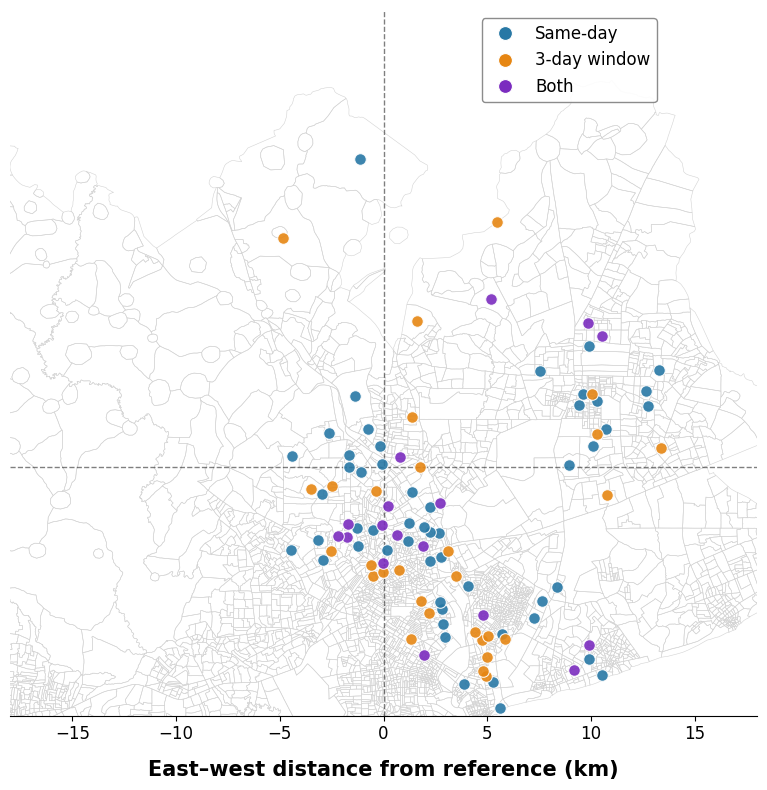

In [60]:
fig, ax, temperature_ea_centroids = (
    plot_ea_risk_distances(
        gdf=merged_risk_gdf,
        base_gdf=filt_all_eas_dem_df_filt,

        # Select one event
        event_filter=None,
        # event_filter='T',

        # Reference based on the full basemap
        use_union_centroid=True,
        use_km=True,
        x_ref_offset=common_x_ref_offset,
        y_ref_offset=common_y_ref_offset,

        # Show full EA basemap
        show_basemap=True,
        basemap_facecolor="none",
        basemap_edgecolor="lightgrey",
        basemap_linewidth=0.4,
        basemap_alpha=1.0,

        # Risk styling
        one_day_color="#2878A5",
        three_day_color="#E68613",
        both_color="#7B2CBF",

        point_size=70,
        point_alpha=0.9,
        point_edgecolor="white",
        point_linewidth=0.8,

        # Axes
        show_yaxis=False,
        figsize=fig_size,

        # Common limits across plots
        xlim=common_xlim,
        ylim=common_ylim,

        # Panel label
        panel_label="",
        panel_label_x=0.02,
        panel_label_y=0.98,

        # Legend
        legend_loc="upper left",
        legend_bbox=(0.62, 1.00),
        legend_frame=True,

        diagnostics=True,

        # Save figure
        save_path=PLOTS_DIR / "all_event_site_1_3_day_outage_odds.png",
        dpi=300
    )
)

In [52]:
merged_risk_gdf[merged_risk_gdf['event'] == 'T']['one_day_risk'].sum()

np.int64(19)

In [53]:
merged_risk_gdf[merged_risk_gdf['event'] == 'T']['three_day_risk'].sum()

np.int64(14)

In [54]:
merged_risk_gdf[merged_risk_gdf['event'] == 'T']['both'].sum()

np.int64(6)